In [1]:
from cil.io import ZEISSDataReader
import numpy as np
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader
import plotly.graph_objects as go
import plot_library as pl
from scipy.ndimage import rotate
from scipy.interpolate import griddata
import SimpleITK as sitk

In [2]:
datapath0 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1.txrm"
reconpath0 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"


datapath1 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_135936/4X_3p1um_60kV_LE1/blackbeauty__4X_3p1um_60kV_LE1.txrm"
reconpath1 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_135936/4X_3p1um_60kV_LE1/blackbeauty__4X_3p1um_60kV_LE1_recon.txm"

datapath2 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_135936/4X_3p1um_60kV_LE1_ymin2800um/blackbeauty__4X_3p1um_60kV_LE1_ymin2800um.txrm"
reconpath2 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_135936/4X_3p1um_60kV_LE1_ymin2800um/blackbeauty__4X_3p1um_60kV_LE1_ymin2800um_recon.txm"


datapath3 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_135936/4X_3p1um_60kV_LE1_yplus2800um/blackbeauty__4X_3p1um_60kV_LE1_yplus2800um.txrm"
reconpath3 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_135936/4X_3p1um_60kV_LE1_yplus2800um/blackbeauty__4X_3p1um_60kV_LE1_yplus2800um_recon.txm"


datapath_neutron = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/P20212875_Nice data/02_rawdata/01_tomo/tomo_00001.fits"
reconpath_neutron = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/P20212875_Nice data/04_evaluation/fullrecon"

In [3]:
reader = ZEISSDataReader(reconpath0)
recon_xray_ = reader.read()
recon_xray = pl.array_normalizer(recon_xray_.as_array().astype(np.float32))

In [4]:
roi = {'axis_0': (100, 1113, 1)}
reader = TIFFStackReader(reconpath_neutron,roi=roi)
recon_neutron = pl.array_normalizer(reader.read())

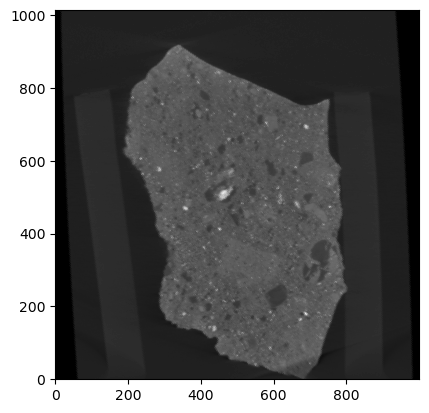

In [5]:
point1 = np.array([44, 26, 35])*20
point2 = np.array([25, 30, 10])*20
point3 = np.array([1, 23, 20])*20
chosen_axis = 1  # This can be 0, 1, or 2
mask, shape_other_axes = pl.plane_mask(matrix_shape = recon_xray.shape, points=(point1,point2, point3),chosen_axis=chosen_axis)
# Extract the slice using the mask
slice_values = recon_xray[mask]

# Reshape for plotting
slice_2d = slice_values.reshape(shape_other_axes)

# Plot the slice
plt.imshow(slice_2d, origin='lower', cmap='gray')
name = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/Skrivebord/DTU/PhD/Conferences/CIL user meeting 2024/fig_xray.png"
plt.savefig(name, format="png",dpi = 500)
plt.show()

In [6]:
block_size = (10,10,10)
recon_xray_d = pl.matrix_downsizer(recon_xray, block_size = block_size)

chosen_axis = 1  # This can be 0, 1, or 2
point1 = np.array([44, 26, 35])*20//block_size[0]
point2 = np.array([25, 30, 10])*20//block_size[1]
point3 = np.array([1, 23, 20])*20//block_size[2]

mask, shape_other_axes = pl.plane_mask(matrix_shape = recon_xray_d.shape, points=(point1,point2, point3),chosen_axis=chosen_axis)
mask = mask*1.0
#pl.render_3d(recon_xray_d, isomin=0.3,isomax = 1, opacity=0.2,plot_plane=True, plane = mask,opacity_plane = 0.01)

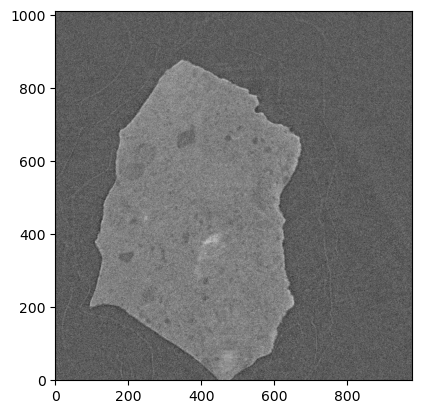

In [7]:
point1 = np.array([1, 20, 33])*15
point2 = np.array([18, 13, 8])*15
point3 = np.array([58, 4, 25])*15
chosen_axis = 1  # This can be 0, 1, or 2
mask, shape_other_axes = pl.plane_mask(matrix_shape = recon_neutron.shape, points=(point1,point2, point3),chosen_axis=chosen_axis)
# Extract the slice using the mask
slice_values = recon_neutron[mask]

# Reshape for plotting
slice_2d = slice_values.reshape(shape_other_axes)

# Plot the slice
plt.imshow(slice_2d, origin='lower', cmap='gray')
name = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/Skrivebord/DTU/PhD/Conferences/CIL user meeting 2024/fig_neutron.png"
plt.savefig(name, format="png",dpi = 500)
plt.show()

In [11]:
block_size = (15,15,15)


recon_neutron_d = pl.matrix_downsizer(recon_neutron, block_size=block_size)
point1 = np.array([1, 20, 33])*15//block_size[0]
point2 = np.array([18, 13, 8])*15//block_size[1]
point3 = np.array([58, 4, 25])*15//block_size[2]
chosen_axis = 1  # This can be 0, 1, or 2

mask, shape_other_axes = pl.plane_mask(matrix_shape = recon_neutron_d.shape, points=(point1,point2, point3),chosen_axis=chosen_axis)
mask = mask*1.0
#pl.render_3d(recon_neutron_d,isomin=0.70,isomax = 1, opacity=0.2,plot_plane=True, plane = mask,opacity_plane = 0.01)

In [12]:
import matplotlib.pyplot as plt

from ipywidgets import interact, fixed
from IPython.display import clear_output


# Callback invoked by the IPython interact method for scrolling through image stacks of
# the two images being registered.
def display_images(fixed_image_z, moving_image_z, fixed_npa, moving_npa):
    # Create a figure with two subplots and the specified size.
    plt.subplots(1, 2, figsize=(10, 8))

    # Draw the fixed image in the first subplot.
    plt.subplot(1, 2, 1)
    plt.imshow(fixed_npa[fixed_image_z, :, :], cmap=plt.cm.Greys_r)
    plt.title("fixed image")
    plt.axis("off")

    # Draw the moving image in the second subplot.
    plt.subplot(1, 2, 2)
    plt.imshow(moving_npa[moving_image_z, :, :], cmap=plt.cm.Greys_r)
    plt.title("moving image")
    plt.axis("off")

    plt.show()


# Callback invoked by the IPython interact method for scrolling and modifying the alpha blending
# of an image stack of two images that occupy the same physical space.
def display_images_with_alpha(image_z, alpha, fixed, moving):
    img = (1.0 - alpha) * fixed[:, :, image_z] + alpha * moving[:, :, image_z]
    plt.imshow(sitk.GetArrayViewFromImage(img), cmap=plt.cm.Greys_r)
    plt.axis("off")
    plt.show()

# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []


# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()


# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values(registration_method):
    global metric_values, multires_iterations

    metric_values.append(registration_method.GetMetricValue())
    # Clear the output area (wait=True, to reduce flickering), and plot current data
    clear_output(wait=True)
    # Plot the similarity metric values
    plt.plot(metric_values, "r")
    plt.plot(
        multires_iterations,
        [metric_values[index] for index in multires_iterations],
        "b*",
    )
    plt.xlabel("Iteration Number", fontsize=12)
    plt.ylabel("Metric Value", fontsize=12)
    plt.show()


# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))


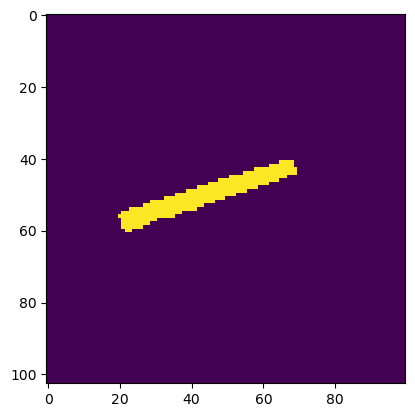

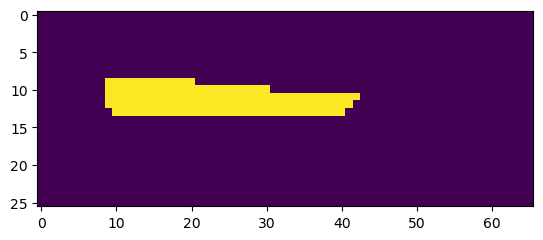

In [14]:
plt.imshow((recon_xray_d[30,:,:]>0.2)*1.0)
plt.show()
plt.imshow((recon_neutron_d[30,:,:]>0.5)*1.0)
plt.show()


In [15]:
def command_iteration(method):
    """ Callback invoked when the optimization process is performing an iteration. """
    print(
        f"{method.GetOptimizerIteration():3} "
        + f"= {method.GetMetricValue():10.5f} "
        + f": {method.GetOptimizerPosition()}"
    )

In [16]:
fixed = sitk.GetImageFromArray((recon_xray_d[:,:,:]>0.2)*1.0)
moving = sitk.GetImageFromArray((recon_neutron_d[:,:,:]>0.5)*1.0)
print(np.mean(recon_neutron_d>0.5))

0.05741807212395448


In [ ]:
# Assume cubic voxels with spacing of 1.0 in each direction
default_spacing = [1.0, 1.0,1.0]  # Adjust the number of dimensions as needed

# Set spacing for original images and print to verify
fixed.SetSpacing(default_spacing[:fixed.GetDimension()])
moving.SetSpacing(default_spacing[:moving.GetDimension()])
fixed = sitk.Cast(fixed, sitk.sitkFloat32)
moving = sitk.Cast(moving, sitk.sitkFloat32)

# Continue with the registration setup
Reg = sitk.ImageRegistrationMethod()
Reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
Reg.SetMetricSamplingStrategy(Reg.RANDOM)
Reg.SetMetricSamplingPercentage(0.2)

# Use a multi-resolution pyramid
Reg.SetShrinkFactorsPerLevel([4, 2, 1,1,1])
Reg.SetSmoothingSigmasPerLevel([3, 2, 1,0.5,0])

# Configure the rigid transform for rotation and translation
initial_transform = sitk.CenteredTransformInitializer(
    fixed,
    moving,
    sitk.Similarity2DTransform() if fixed.GetDimension() == 2 else sitk.Similarity3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)
Reg.SetInitialTransform(initial_transform, inPlace=False)
Reg.SetOptimizerAsGradientDescent(learningRate=1,
                                   numberOfIterations=2000,
                                   convergenceMinimumValue=1e-6,
                                     convergenceWindowSize=10)
Reg.SetOptimizerScalesFromPhysicalShift()
Reg.SetInterpolator(sitk.sitkLinear)

#Reg.SetOptimizerScalesFromJacobian()
#Reg.SetMetricSamplingPercentage(0.2)  # Use a percentage of the image for metric computation
#Reg.SetOptimizerAsGradientDescent(learningRate=1.0, numberOfIterations=100)
#Reg.SetMetricAsMeanSquares()  # Or any other metric

# Optionally, add a command to print iteration progress
def command_iteration(method):
    print("Optimizer Iteration:", method.GetOptimizerIteration(), "Metric Value:", method.GetMetricValue())

#Reg.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(Reg))

# Execute the registration
final_transform = Reg.Execute(fixed, moving)

transformed_moving_image = sitk.Resample(moving, fixed, final_transform, 
                                         sitk.sitkLinear, 0.1, fixed.GetPixelID())

# Print out the transformation details based on the type of transform
print("Final Transformation Parameters:")

if isinstance(final_transform, sitk.CompositeTransform):
    # Get the first sub-transform, which should be the actual one applied
    final_transform = final_transform.GetNthTransform(0)

# Now print the parameters based on the actual transform type
print("Base Transformation Type:", type(final_transform))
if isinstance(final_transform, sitk.Euler2DTransform):
    angle, tx, ty = final_transform.GetParameters()
    print("Rotation (radians):", angle)
    print("Translation in x:", tx)
    print("Translation in y:", ty)
elif isinstance(final_transform, sitk.Similarity2DTransform):
    scale, angle, tx, ty = final_transform.GetParameters()
    print('Scaling in x,y:', scale)
    print("Rotation (radians):", angle)
    print("Translation in x:", tx)
    print("Translation in y:", ty)
elif isinstance(final_transform, sitk.Euler3DTransform):
    rx, ry, rz, tx, ty, tz = final_transform.GetParameters()
    print("Transformation is Euler3D:")
    print("Rotation around x (radians):", rx)
    print("Rotation around y (radians):", ry)
    print("Rotation around z (radians):", rz)
    print("Translation in x:", tx)
    print("Translation in y:", ty)
    print("Translation in z:", tz)
elif isinstance(final_transform, sitk.Similarity3DTransform):
    rx, ry, rz, tx, ty, tz, scale = final_transform.GetParameters()
    print("Transformation is Similarity3D:")
    print("Rotation around x (radians):", rx)
    print("Rotation around y (radians):", ry)
    print("Rotation around z (radians):", rz)
    print("Translation in x:", tx)
    print("Translation in y:", ty)
    print("Translation in z:", tz)
    print("Uniform Scale:", scale)
else:
    print("No valid transform found.")

Final Transformation Parameters:
Base Transformation Type: <class 'SimpleITK.SimpleITK.Similarity3DTransform'>
Transformation is Similarity3D:
Rotation around x (radians): 0.19402921869528028
Rotation around y (radians): -0.12027282941541019
Rotation around z (radians): 0.17109094344405207
Translation in x: -23.66777780322425
Translation in y: -43.56833780846946
Translation in z: -30.58818946896003
Uniform Scale: 0.7740572109383246


(102, 103, 100)


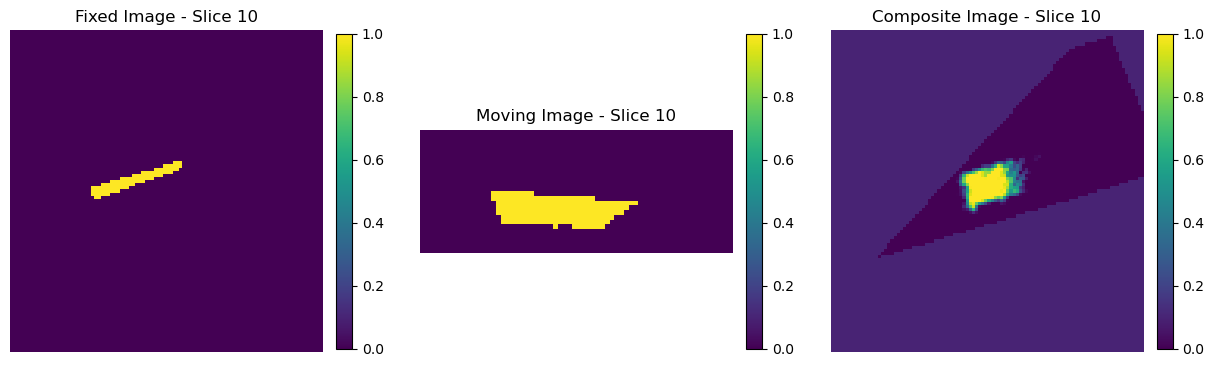

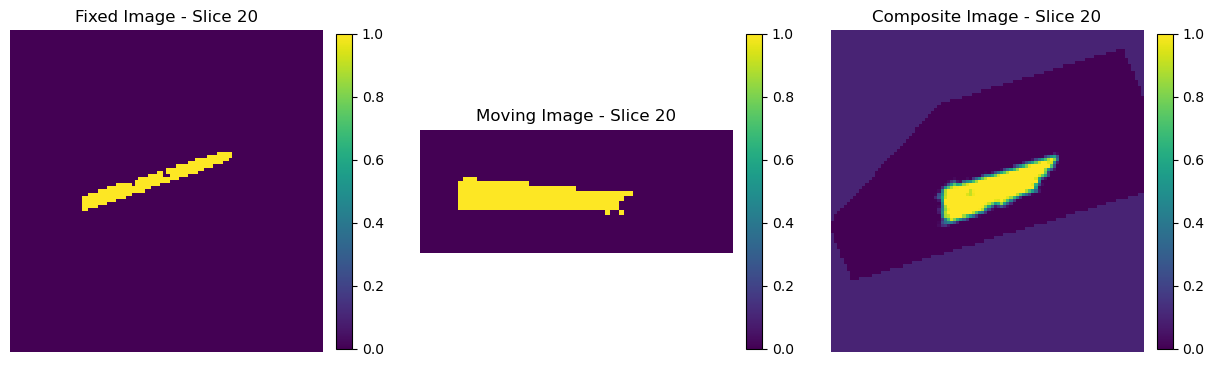

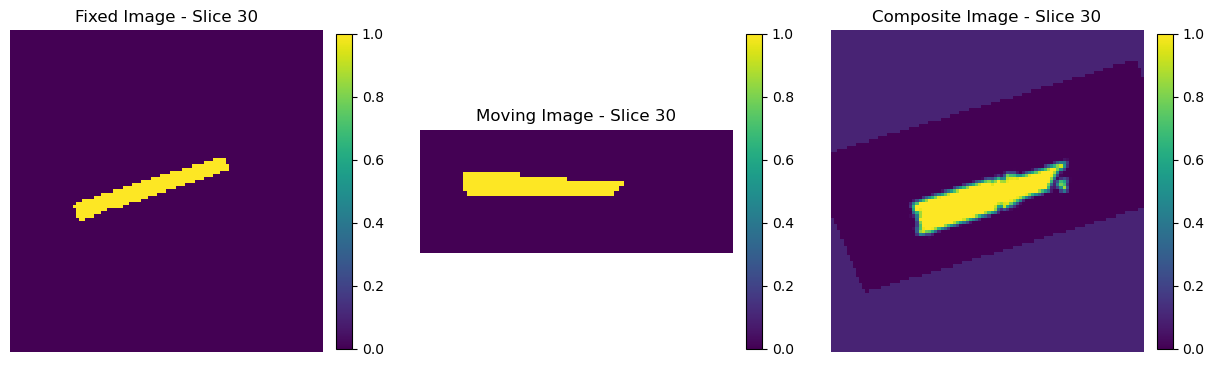

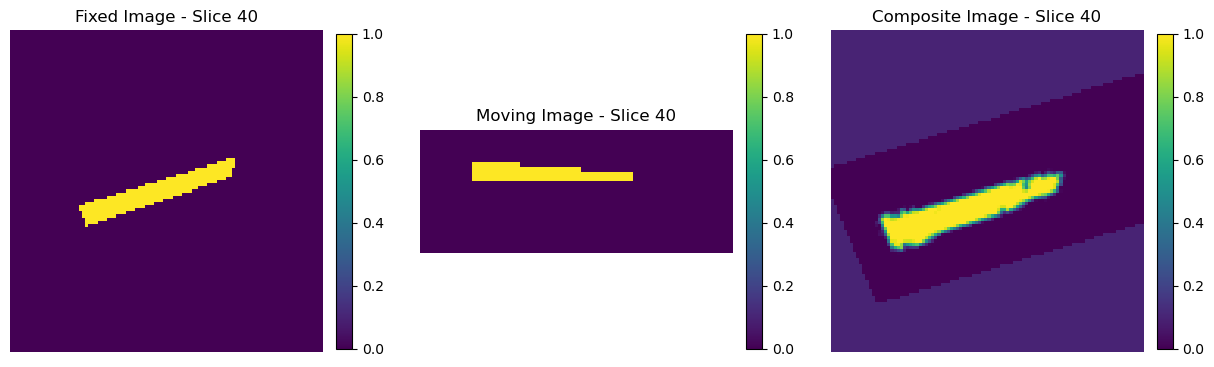

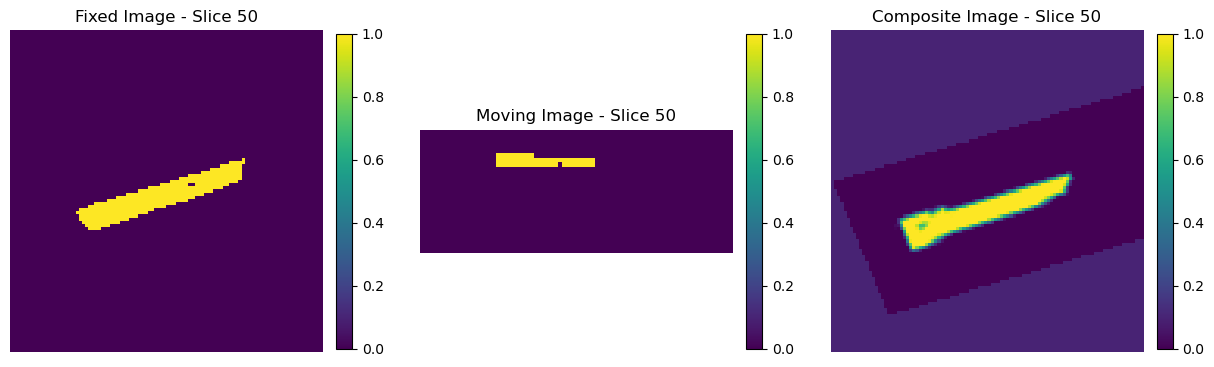

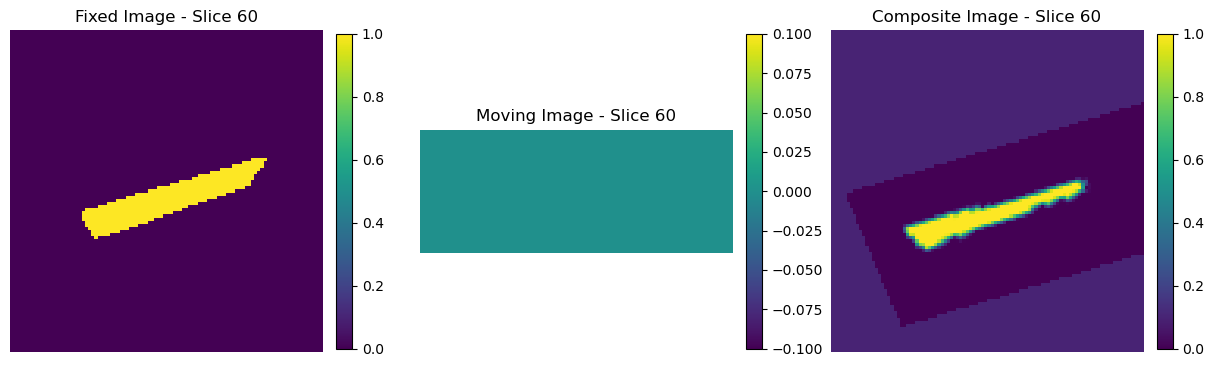

In [162]:
simg1_array = sitk.GetArrayFromImage(fixed)
simg2_array = sitk.GetArrayFromImage(moving)
cimg_array = sitk.GetArrayFromImage(transformed_moving_image)
print(np.shape(cimg_array))

#print(np.max(simg1_array),np.min(simg1_array))
#print(np.max(simg2_array), np.min(simg2_array))

# Define the number of slices (assumes the images have the same depth)

# Plot each slice in a loop
slices = (10,20,30,40,50,60)
for i in slices:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Display the fixed image slice
    im1 = axes[0].imshow(simg1_array[i,:, :], cmap="viridis")
    axes[0].set_title(f'Fixed Image - Slice {i}')
    axes[0].axis('off')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Display the transformed moving image slice
    im2 = axes[1].imshow(simg2_array[i,:, :], cmap="viridis")
    axes[1].set_title(f'Moving Image - Slice {i}')
    axes[1].axis('off')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Display the composite image slice
    im3 = axes[2].imshow(cimg_array[i,:, :], cmap="viridis")
    axes[2].set_title(f'Composite Image - Slice {i}')
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    plt.show()


In [163]:
print(cimg_array[25:35,20:25])

[[[0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]]

 [[0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]]

 [[0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]]

 ...

 [[0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]]

 [[0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]]

 [[0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]
  [0.1 0.1 0.1 ... 0.  0.  0. ]]]


In [166]:
transformed_moving_image.GetDirection()


(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)